# Intro
Intro basée sur l'article, dire que les ramsomware c'est un type de virus, et que les transactions bitcoin ont permis de rendre le truc anonyme et plus facile. Donc faudrait être en mesure de les détecter avant.
Etat de l'art c'est que il n'y a que des méthodes heuristiques pour le moment, et faudrait faire des méthodes de machine learning.


In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timezone
import seaborn as sns
import plotly.express as px

from IPython.display import display

In [3]:
data = pd.read_csv("BitcoinHeistData.csv")

In [4]:
data.head()

,address,year,day,length,weight,count,looped,neighbors,income,label
0,111K8kZAEnJg245r2cM6y9zgJGHZtJPy6,2017,11,18,0.008333,1,0,2,100050000.0,princetonCerber
1,1123pJv8jzeFQaCV4w644pzQJzVWay2zcA,2016,132,44,0.000244,1,0,1,100000000.0,princetonLocky
2,112536im7hy6wtKbpH1qYDWtTyMRAcA2p7,2016,246,0,1.000000,1,0,2,200000000.0,princetonCerber
3,1126eDRw2wqSkWosjTCre8cjjQW8sSeWH7,2016,322,72,0.003906,1,0,2,71200000.0,princetonCerber
4,1129TSjKtx65E35GiUo4AYVeyo48twbrGX,2016,238,144,0.072848,456,0,1,200000000.0,princetonLocky


In [5]:
data.columns[:-1].to_list()  # Exclude the target column




['address',
 'year',
 'day',
 'length',
 'weight',
 'count',
 'looped',
 'neighbors',
 'income']

## Description des variables

Chaque ligne décrit une adresse Bitcoin et les caractéristiques de son activité dans le graphe de transactions.

| Variable | Description |
|---|---|
| `address` | Identifiant public de l'adresse Bitcoin. Ce n'est pas une mesure numérique : il est généralement préférable de ne pas l'utiliser directement comme entrée d'un modèle. |
| `year` | Année de l'observation. Elle situe l'activité dans le temps et peut refléter des changements historiques dans les campagnes ou les pratiques de paiement. |
| `day` | Jour de l'année, de 1 à 365 (ou 366). Par exemple, `132` est le 132e jour de l'année, et non le 132e jour du mois. |
| `length` | Longueur du chemin ou de la chaîne de transactions associée à l'adresse, mesurée en nombre d'étapes. Une valeur élevée indique un parcours plus long et plus complexe. |
| `weight` | Poids relatif de la chaîne ou du parcours étudié dans le graphe. C'est une proportion sans unité, généralement comprise entre 0 et 1 : une valeur proche de 1 indique une chaîne dominante. |
| `count` | Nombre total de transactions associées à l'adresse dans le graphe étudié. Il mesure l'activité transactionnelle, mais ne suffit pas à lui seul à identifier une adresse malveillante. |
| `looped` | Nombre de transactions qui participent à des boucles dans le graphe. Les boucles correspondent à des flux qui reviennent vers une adresse ou un ensemble d'adresses déjà rencontré. |
| `neighbors` | Nombre d'adresses directement connectées à l'adresse par une transaction entrante ou sortante. Il s'agit du degré local du nœud dans le graphe Bitcoin. |
| `income` | Montant total reçu par l'adresse, exprimé en satoshis. `100 000 000` satoshis = `1 BTC`; ainsi `100050000.0` correspond à `1.0005 BTC`. |
| `label` | Classe cible à prédire, par exemple `princetonCerber` ou `princetonLocky`. Elle n'est pas une feature : elle sert de variable de sortie (`target`). |

### Pour la modélisation :

- `address` est un identifiant et ne possède pas de valeur concrète ; il faut l'exclure ou l'encoder.
- `label` ne doit pas être utilisée comme entrée.
- `length`, `count`, `looped` et `neighbors` sont des comptages, `weight` est une proportion et `income` est un montant en satoshis. Une standardisation ou une transformation logarithmique peut être utile pour certains modèles.
- `year` et `day` sont temporelles ; `day` peut être transformée en variable cycliques afin de représenter la périodicité du calendrier.


In [6]:
features = data.columns[:-1].to_list()[3:]  # on enlève la colonne target et les colonnes "address", "year" et "day" qui ne sont pas des features
numeric_cols = ["year", "day"] + features
integer_cols = [c for c in numeric_cols if c != "weight"]
required_cols = ["address"] + numeric_cols + ["label"]

if not data.columns.is_unique:
    raise ValueError("Certains noms de colonnes sont dupliqués.")

df = data.copy() #on va travailler avec df pour ne pas modifier le dataset original
n_initial = len(df)
n_duplicates = int(df.duplicated().sum())
df = df.drop_duplicates().copy()

print(f"Lignes initiales : {n_initial:,}")
print(f"Doublons stricts retirés : {n_duplicates:,}")

Lignes initiales : 2,916,697
Doublons stricts retirés : 0


In [7]:
labels = data["label"].values 
types_of_labels = np.unique(labels)
types_of_labels

array(['montrealAPT', 'montrealComradeCircle', 'montrealCryptConsole',
       'montrealCryptXXX', 'montrealCryptoLocker',
       'montrealCryptoTorLocker2015', 'montrealDMALocker',
       'montrealDMALockerv3', 'montrealEDA2', 'montrealFlyper',
       'montrealGlobe', 'montrealGlobeImposter', 'montrealGlobev3',
       'montrealJigSaw', 'montrealNoobCrypt', 'montrealRazy',
       'montrealSam', 'montrealSamSam', 'montrealVenusLocker',
       'montrealWannaCry', 'montrealXLocker', 'montrealXLockerv5.0',
       'montrealXTPLocker', 'paduaCryptoWall', 'paduaJigsaw',
       'paduaKeRanger', 'princetonCerber', 'princetonLocky', 'white'],
      dtype=object)

`white` correspond à une adresse non connue comme un ransomware. Attention, ce n'est pas un innoncent confirmé. Le but de cette analyse sera de détecter quelles adresses avec un label `white` sont malveillantes, basé sur leur activité précédente.

### Nettoyage et ajustement des données

In [8]:
# Compter les manquants avant toute conversion, après retrait des doublons.
missing_before = df[required_cols].isna().sum()

# Une chaîne vide est aussi une donnée manquante.
for col in ["address", "label"]:
    df[col] = df[col].astype("string").str.strip().replace("", pd.NA)

conversion_report = []

for col in numeric_cols:
    original = df[col]
    converted = pd.to_numeric(original, errors="coerce")

    # Un texte non convertible devient NaN ; un infini devient également NaN.
    n_unreadable = int((original.notna() & converted.isna()).sum())
    n_infinite = int(converted.isin([np.inf, -np.inf]).sum())
    df[col] = converted.replace([np.inf, -np.inf], np.nan)

    conversion_report.append({
        "variable": col,
        "non_convertibles": n_unreadable,
        "infinis": n_infinite,
    })

display(pd.DataFrame(conversion_report).set_index("variable"))

missing_report = pd.DataFrame({
    "manquantes_initiales": missing_before,
    "manquantes_apres_conversion": df[required_cols].isna().sum(),
})
display(missing_report)

print(
    "Lignes avec au moins une valeur manquante :",
    int(df[required_cols].isna().any(axis=1).sum())
)

# Les mesures doivent être non négatives.
negative_rows = df[numeric_cols].lt(0).any(axis=1)

# Les comptes, années et jours doivent être entiers.
# Une valeur absente sera traitée à l'étape suivante, pas comme un entier invalide.
fractional_rows = (
    df[integer_cols].notna() & df[integer_cols].mod(1).ne(0)
).any(axis=1)

start_date = pd.Timestamp("2009-01-01")
today = pd.Timestamp("2026-10-01") #pour la reproductibilité, on fixe la date du jour au premier octobre 2026

year = df["year"]
day = df["day"]

# Une année bissextile est divisible par 4, sauf certains siècles.
leap_year = (
    year.mod(4).eq(0)
    & (year.mod(100).ne(0) | year.mod(400).eq(0))
)
max_day = pd.Series(np.where(leap_year.fillna(False), 366, 365), index=df.index)

valid_year = year.between(2009, today.year) & year.mod(1).eq(0)
valid_day = day.ge(1) & day.le(max_day) & day.mod(1).eq(0)

# Construire le 1er janvier, puis ajouter day - 1 jours.
# Int64 accepte les entiers manquants, contrairement au type int classique.
year_start = pd.to_datetime(
    year.where(valid_year).astype("Int64").astype("string"),
    format="%Y",
    errors="coerce",
)
df["date"] = year_start + pd.to_timedelta(
    day.where(valid_day) - 1, unit="D"
)

# Si année et jour sont présents, la date doit être valide et non future.
has_date_fields = df[["year", "day"]].notna().all(axis=1)
invalid_date_rows = (
    has_date_fields & ~df["date"].between(start_date, today)
)

# Les motifs peuvent se recouper : une ligne ne sera retirée qu'une seule fois.
invalid_rows = negative_rows | fractional_rows | invalid_date_rows

display(pd.Series({
    "lignes_avec_negatif": int(negative_rows.sum()),
    "lignes_avec_entier_fractionnaire": int(fractional_rows.sum()),
    "lignes_avec_date_invalide": int(invalid_date_rows.sum()),
    "lignes_invalides_distinctes": int(invalid_rows.sum()),
}, name="effectif").to_frame())

# Conserver les lignes invalides pour pouvoir les examiner.
data_invalid = df.loc[invalid_rows].copy()
df = df.loc[~invalid_rows].copy()


,non_convertibles,infinis
variable,,
year,0,0
day,0,0
length,0,0
weight,0,0
count,0,0
looped,0,0
neighbors,0,0
income,0,0


,manquantes_initiales,manquantes_apres_conversion
address,0,0
year,0,0
day,0,0
length,0,0
weight,0,0
count,0,0
looped,0,0
neighbors,0,0
income,0,0
label,0,0


Lignes avec au moins une valeur manquante : 0


,effectif
lignes_avec_negatif,0
lignes_avec_entier_fractionnaire,0
lignes_avec_date_invalide,0
lignes_invalides_distinctes,0


Tout est intact dans notre dataset, il ne manque aucune valeur, elles sont toutes positives et il n'y a pas de valeur aberrante, que ça soit numérique ou une date.
On va procéder à un audit de toutes nos colonnes : 

In [9]:
# Audit de toutes les colonnes
data_clean = required_cols + ["date"]
data_clean = df[data_clean].copy()
audit = pd.DataFrame({
    "type": data_clean.dtypes.astype(str),
    "nb_manquantes": data_clean.isna().sum(),
    "nb_distinctes": data_clean.nunique(),
})

# Les quantiles ne s'appliquent qu'aux colonnes numériques du schéma.
stats = data_clean[numeric_cols].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T.drop(columns="count")

stats = stats.rename(columns={
    "mean": "moyenne", "std": "ecart_type",
    "1%": "p01", "25%": "p25", "50%": "mediane",
    "75%": "p75", "99%": "p99",
})

audit = audit.join(stats)
audit["nb_zeros"] = data_clean[numeric_cols].eq(0).sum()
display(audit.round(3))

# Conserver les familles originales pour les analyses ultérieures.
label_counts = data_clean["label"].value_counts()
display(pd.DataFrame({
    "nb_lignes": label_counts,
    "pourcentage": 100 * label_counts / len(data_clean),
}).round(3))

print("Période :", data_clean["date"].min(), "→", data_clean["date"].max())
print("Adresses distinctes :", data_clean["address"].nunique())


,type,nb_manquantes,nb_distinctes,moyenne,ecart_type,min,p01,p25,mediane,p75,p99,max,nb_zeros
address,string,0,2631095,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,int64,0,8,2.014475e+03,2.257000e+00,2011.0,2011.0,2.013000e+03,2.014000e+03,2.016000e+03,2.018000e+03,2.018000e+03,0.0
day,int64,0,365,1.814570e+02,1.040120e+02,1.0,4.0,9.200000e+01,1.810000e+02,2.710000e+02,3.610000e+02,3.650000e+02,0.0
length,int64,0,73,4.500900e+01,5.898200e+01,0.0,0.0,2.000000e+00,8.000000e+00,1.080000e+02,1.440000e+02,1.440000e+02,708621.0
weight,float64,0,784927,5.460000e-01,3.674000e+00,0.0,0.0,2.100000e-02,2.500000e-01,8.820000e-01,3.417000e+00,1.943749e+03,0.0
count,int64,0,11572,7.216450e+02,1.689676e+03,1.0,1.0,1.000000e+00,1.000000e+00,5.600000e+01,7.725000e+03,1.449700e+04,0.0
looped,int64,0,10168,2.385070e+02,9.663220e+02,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,5.391000e+03,1.449600e+04,2504877.0
neighbors,int64,0,814,2.207000e+00,1.791900e+01,1.0,1.0,1.000000e+00,2.000000e+00,2.000000e+00,8.000000e+00,1.292000e+04,0.0
income,float64,0,1866365,4.464889e+09,1.626860e+11,30000000.0,30500000.0,7.428559e+07,1.999985e+08,9.940000e+08,4.642012e+10,4.996440e+13,0.0
label,string,0,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,nb_lignes,pourcentage
label,,
white,2875284,98.58
paduaCryptoWall,12390,0.425
montrealCryptoLocker,9315,0.319
princetonCerber,9223,0.316
princetonLocky,6625,0.227
montrealCryptXXX,2419,0.083
montrealNoobCrypt,483,0.017
montrealDMALockerv3,354,0.012
montrealDMALocker,251,0.009


Période : 2011-01-01 00:00:00 → 2018-11-26 00:00:00
Adresses distinctes : 2631095


In [10]:
# 1. Observations multiples pour une même adresse et une même date.
repeated_key = data_clean.duplicated(["address", "date"], keep=False)

# 2. Par définition, les starters à plusieurs chemins sont un sous-ensemble
# des starters qui atteignent l'adresse : looped devrait être <= count.
topology_issue = data_clean["looped"].gt(data_clean["count"])

print("Lignes partageant une clé adresse-date :", int(repeated_key.sum()))
print("Lignes avec looped > count :", int(topology_issue.sum()))

Lignes partageant une clé adresse-date : 0
Lignes avec looped > count : 0


### Un premier Pair-Plot

,effectif_affiche
classe,
Ransomware identifié,2000
White — non identifié,2000


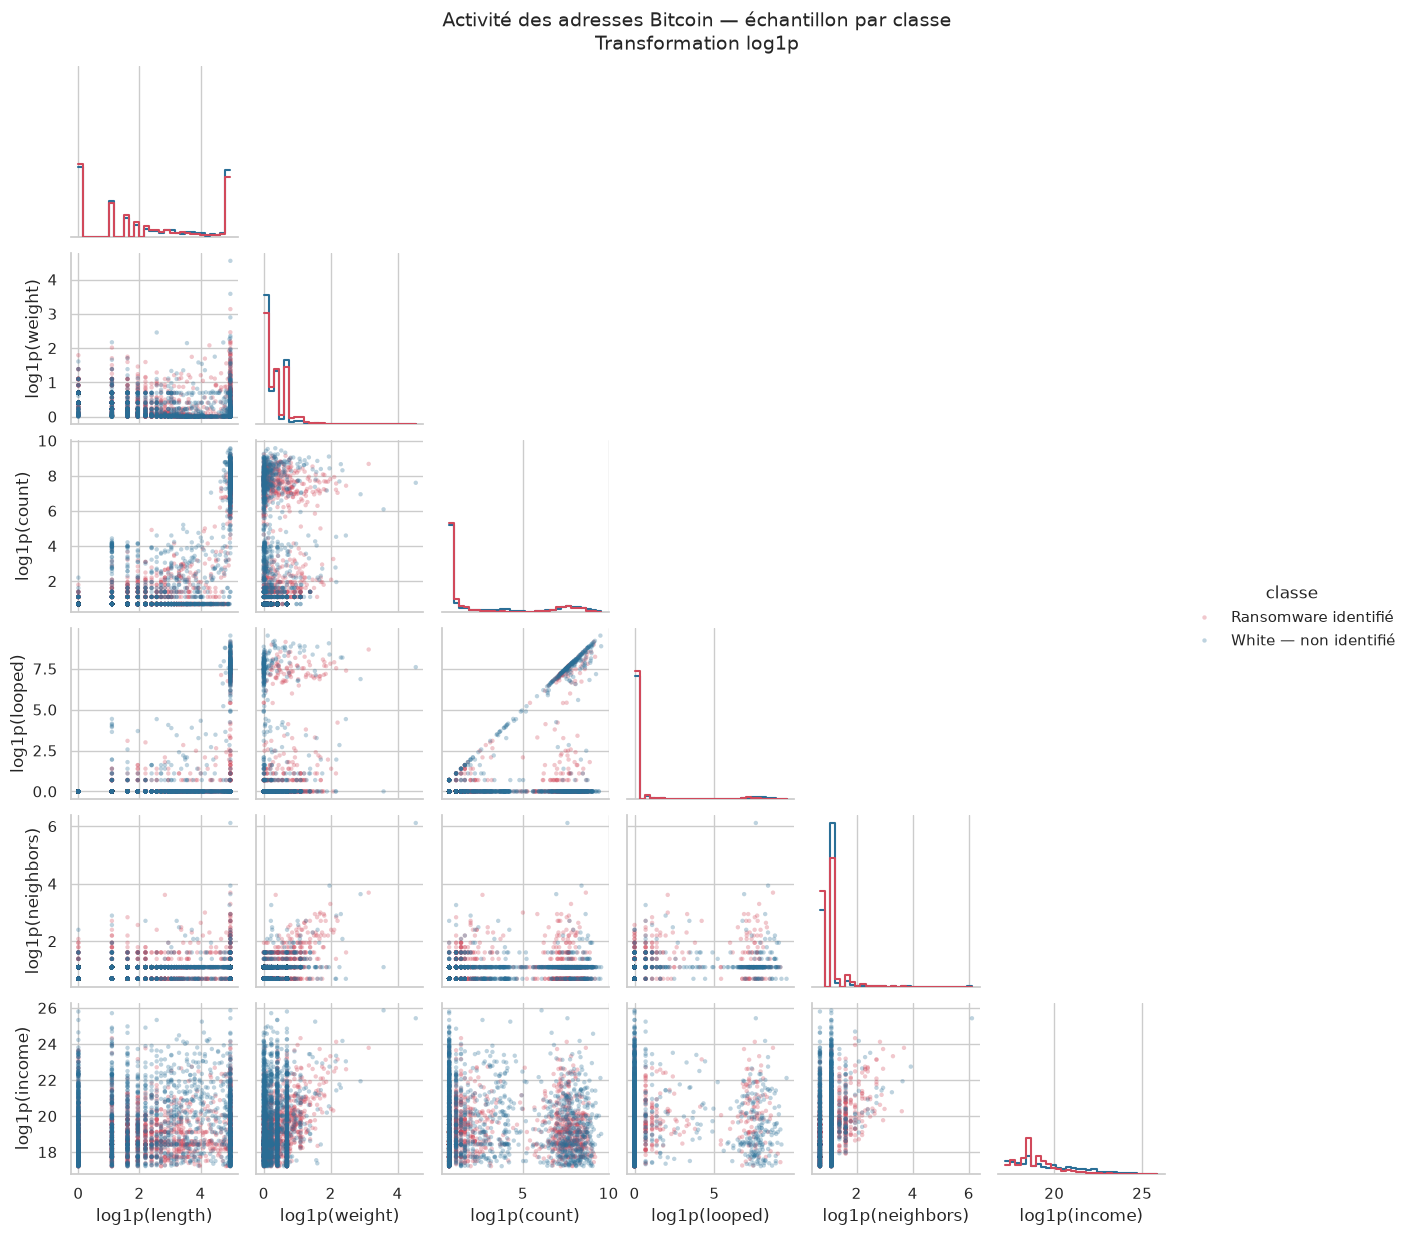

In [11]:
sns.set_theme(style="whitegrid", context="notebook")

# Regroupement uniquement pour le graphique ; label reste inchangé.
viz = data_clean[features + ["label"]].copy()
viz["classe"] = np.where(
    viz["label"].eq("white"), "White — non identifié", "Ransomware identifié"
)

# Maximum 2 000 observations par classe : rapide et lisible.
max_obs = 2_000
samples = []
for _, group in viz.groupby("classe"):
    samples.append(group.sample(n=min(max_obs, len(group)), random_state=42))
viz = pd.concat(samples, ignore_index=True)

# Même échantillon pour les versions brute et logarithmique.
USE_LOG = True

if USE_LOG:
    viz[features] = np.log1p(viz[features])
    names = {c: f"log1p({c})" for c in features}
    viz = viz.rename(columns=names)
    plot_features = list(names.values())
else:
    plot_features = features

display(viz["classe"].value_counts().rename("effectif_affiche").to_frame())

grid = sns.pairplot(
    viz,
    vars=plot_features,
    hue="classe",
    palette={
        "White — non identifié": "#2A6F97",
        "Ransomware identifié": "#D1495B",
    },
    corner=True,
    diag_kind="hist",
    height=2.0,
    plot_kws={"s": 10, "alpha": 0.3, "linewidth": 0, "rasterized": True},
    diag_kws={
        "bins": 30, "stat": "density",
        "common_norm": False, "element": "step", "fill": False,
    },
)
grid.figure.suptitle(
    "Activité des adresses Bitcoin — échantillon par classe\n"
    + ("Transformation log1p" if USE_LOG else "Unités brutes"),
    y=1.03,
    fontsize=14,
)
plt.show()




####### pour le faire en mode interactif : 


# # La couleur représente la classe ; les familles originales sont conservées.
# viz = data_clean[features + ["address", "date", "label"]].copy()
# viz["classe"] = np.where(
#     viz["label"].eq("white"), "White — non identifié", "Ransomware identifié"
# )

# # Garder un nombre limité de points pour que le zoom reste fluide.
# samples = []
# for _, group in viz.groupby("classe"):
#     samples.append(group.sample(n=min(2_000, len(group)), random_state=42))
# viz = pd.concat(samples, ignore_index=True)

# # Afficher au survol la journée et le montant original, même en mode logarithmique.
# viz["date"] = viz["date"].dt.strftime("%Y-%m-%d")
# viz["income_brut"] = viz["income"]

# # Modifier ce paramètre et réexécuter la cellule pour comparer les deux échelles.
# USE_LOG = True
# if USE_LOG:
#     viz[features] = np.log1p(viz[features])

# labels = {c: f"{c} · log1p" if USE_LOG else c for c in features}
# labels.update({
#     "classe": "Classe",
#     "label": "Étiquette originale",
#     "date": "Journée",
#     "income_brut": "Income brut",
# })

# display(viz["classe"].value_counts().rename("effectif_affiche").to_frame())

# fig = px.scatter_matrix(
#     viz,
#     dimensions=features,
#     color="classe",
#     color_discrete_map={
#         "White — non identifié": "#2A6F97",
#         "Ransomware identifié": "#D1495B",
#     },
#     hover_name="address",
#     hover_data={"date": True, "label": True, "income_brut": ":,.0f"},
#     labels=labels,
#     title=(
#         "Activité des adresses Bitcoin — échantillon par classe"
#         + ("<br><sup>Échelles log1p ; proportions non représentatives du dataset</sup>"
#            if USE_LOG else
#            "<br><sup>Unités brutes ; proportions non représentatives du dataset</sup>")
#     ),
#     height=1_050,
#     width=1_150,
# )

# # Ne montrer qu'une fois chaque paire de variables.
# # La diagonale est masquée : les histogrammes sont à tracer séparément.
# fig.update_traces(
#     diagonal_visible=False,
#     showupperhalf=False,
#     marker={"size": 4, "opacity": 0.45, "line": {"width": 0}},
# )

# fig.update_layout(
#     template="plotly_white",
#     dragmode="zoom",
#     hovermode="closest",
#     font={"family": "Arial", "size": 11},
#     legend={"orientation": "h", "y": 1.04, "x": 0},
#     margin={"l": 80, "r": 30, "t": 150, "b": 80},
# )

# # Zoom à la molette et export PNG de grande taille avec le bouton appareil photo.
# config = {
#     "scrollZoom": True,
#     "displaylogo": False,
#     "responsive": True,
#     "doubleClick": "reset",
#     "toImageButtonOptions": {
#         "format": "png",
#         "filename": "pairplot_bitcoinheist",
#         "width": 1_600,
#         "height": 1_450,
#         "scale": 2,
#     },
# }

# fig.show(config=config)

# # Facultatif : conserver un graphique interactif autonome, ouvrable dans un navigateur.
# # fig.write_html("pairplot_bitcoinheist.html", include_plotlyjs=True, config=config)



,effectif_affiche
classe,
Ransomware identifié,2000
White — non identifié,2000
